# HMM4 — HMM con 3 estados (migración real / commute activo / estacionario)

Variante experimental de HMM2 que rompe deliberadamente la restricción `n_components = 2` impuesta por la profesora, con un único objetivo: comprobar empíricamente la **caveat 1 de la Fase 5** de `HMM2_plan.md`, según la cual el estado "migración" del HMM2 mezcla dos comportamientos distintos:

- **Vuelos largos reales** (step > 100 km, ~28 % de los días "migración" en HMM2).
- **Commutes activos intra-residencia** (step 20–100 km, ~72 %).

La hipótesis es que con `n_components = 3` el modelo separa esos dos modos en estados distintos, dejando un tercer estado como descanso. Esto debería resolver indirectamente cuatro síntomas observados en HMM2:

1. `|turning_angle|` medio en migración = 1,52 rad (~87°), demasiado alto para vuelo recto.
2. 14–21 % de "migración" incluso en verano (cría), donde no debería haber migración real.
3. 31 % de las rachas de migración duran 1 solo día.
4. La duración media del estado estacionario sale 12,1 días (no semanas/meses) porque cualquier commute > 25 km rompe la racha.

**Convención de etiquetas (3 estados)** — preserva la convención de HMM2/HMM3 para `0` y `1`:

```
estado_hmm = 0  →  migración real      (mayor media de step)
estado_hmm = 1  →  estacionario        (menor media de step)
estado_hmm = 2  →  commute activo      (media intermedia)
```

El resto del diseño es **idéntico a HMM2**: mismas features (`step_length` en km bruto + `cos(turning_angle)`), `covariance_type='diag'`, `n_iter=200`, `tol=1e-4`, 15 inicializaciones aleatorias, `lengths=` por `trayectoria_id`, sin StandardScaler.

Salida: `data/processed/hmm4.csv` (mismas 12 columnas que `hmm2.csv`).

HMM4 es un **experimento exploratorio**, no un sustituto de HMM2. La defensa del TFG sigue apoyándose en HMM2 (que respeta la restricción de la profesora). HMM4 sirve para cuantificar qué se gana al relajar esa restricción.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Carga del CSV limpio

Entrada: `data/processed/aves_procesado_markov.csv`, producido por `dataExploration1.ipynb` (1 fila/(ave, día) hacia las 14h, segmentos continuos de ≥4 días por `trayectoria_id`).

In [2]:
df = pd.read_csv('../data/processed/aves_procesado_markov.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['trayectoria_id', 'date']).reset_index(drop=True)

print(f'Filas: {len(df):,}')
print(f'Aves únicas: {df["animal_id"].nunique()}')
print(f'Trayectorias: {df["trayectoria_id"].nunique()}')
print(f'Rango temporal: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Filas: 22,041
Aves únicas: 117
Trayectorias: 480
Rango temporal: 2009-05-25 → 2015-08-23


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id
0,91732A,2010-04-18,14,32.6790,29.1823,0.0032,0.0001,91732A_Seg10
1,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10
2,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10
3,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10
4,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10


## 2. Features de movimiento

Para cada `trayectoria_id`:

- `step_length` = haversine entre día t y día t+1, en km.
- `bearing` = great-circle initial bearing entre los mismos dos puntos, en grados [0, 360).
- `turning_angle` = cambio de rumbo entre pasos consecutivos, normalizado a [-π, π] en radianes.

Las funciones `haversine_km` y `calculate_bearing` son las mismas que en `HMM.ipynb` — están geométricamente correctas.

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia haversine entre dos puntos (lat, lon) en grados, en km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def calculate_bearing(lat1, lon1, lat2, lon2):
    """Rumbo great-circle inicial en grados [0, 360); 0=norte, sentido horario."""
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2 - lon1)
    y = np.sin(dlambda) * np.cos(phi2)
    x = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlambda)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360

In [4]:
df['next_lat'] = df.groupby('trayectoria_id')['lat'].shift(-1)
df['next_lon'] = df.groupby('trayectoria_id')['lon'].shift(-1)

df['step_length'] = haversine_km(df['lat'], df['lon'], df['next_lat'], df['next_lon'])
df['bearing'] = calculate_bearing(df['lat'], df['lon'], df['next_lat'], df['next_lon'])

delta_bearing = df.groupby('trayectoria_id')['bearing'].diff()
df['turning_angle'] = np.arctan2(
    np.sin(np.radians(delta_bearing)),
    np.cos(np.radians(delta_bearing)),
)

print('NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):')
print(df[['step_length', 'bearing', 'turning_angle']].isna().sum())

NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):
step_length      480
bearing          480
turning_angle    960
dtype: int64


In [5]:
# Quitar filas sin step_length (último día de cada trayectoria) y sin turning_angle (primer día).
# Mantenemos el orden por (trayectoria_id, date) para que `lengths=` luego cuadre.
df_hmm = df.dropna(subset=['step_length', 'turning_angle']).reset_index(drop=True)
print(f'Filas tras limpieza: {len(df_hmm):,} (eliminadas {len(df) - len(df_hmm)})')
df_hmm[['animal_id', 'trayectoria_id', 'date', 'step_length', 'bearing', 'turning_angle']].head()

Filas tras limpieza: 21,081 (eliminadas 960)


,animal_id,trayectoria_id,date,step_length,bearing,turning_angle
0,91732A,91732A_Seg10,2010-04-19,8.9980,334.1859,-0.2347
1,91732A,91732A_Seg10,2010-04-20,13.8990,169.7393,-2.8701
2,91732A,91732A_Seg10,2010-04-21,13.5890,353.8284,-3.0702
3,91732A,91732A_Seg10,2010-04-22,14.1345,186.9951,-2.9118
4,91732A,91732A_Seg10,2010-04-23,24.3664,5.8214,3.1211


## 3. Matriz de observaciones

Decisión de diseño tras un experimento fallido (ver `HMM2_plan.md`, sección "Lección aprendida"): **dejamos `step_length` en su escala natural en km** y **no aplicamos `StandardScaler`**. La distribución de `step_length` es claramente bimodal en este dataset (pico 0–5 km de descanso, cola 50–200+ km de migración) y esa varianza enorme es precisamente la señal que el HMM necesita para separar los dos modos. Aplicar log + escalado diluye esa bimodalidad y el modelo se latcha a otro eje (lo que pasó en v1).

- `step_length` (km, raw): la varianza enorme domina la verosimilitud Gaussian → fuerza al modelo a separar por velocidad.
- `cos_turn = cos(turning_angle)` ∈ [-1, 1]: convierte la variable circular en un real, vale 1 cuando el ave sigue recta y -1 cuando se da media vuelta. Actúa como feature secundaria que refina ligeramente la separación.


In [6]:
df_hmm['cos_turn'] = np.cos(df_hmm['turning_angle'])

# X tiene step_length en km (sin transformar) y cos(turning_angle) en [-1, 1].
# NO aplicamos StandardScaler: queremos que la varianza enorme de step_length
# domine la verosimilitud Gaussian para que el HMM separe los modos por velocidad.
X = df_hmm[['step_length', 'cos_turn']].values

print(f'X.shape = {X.shape}')
print('Estadísticas (sin escalar — varianzas dispares a propósito):')
print(pd.DataFrame({
    'mean': X.mean(axis=0),
    'std': X.std(axis=0),
    'min': X.min(axis=0),
    'max': X.max(axis=0),
}, index=['step_length (km)', 'cos_turn']))

X.shape = (21081, 2)
Estadísticas (sin escalar — varianzas dispares a propósito):
                    mean      std     min       max
step_length (km) 30.7354 109.1007  0.0000 1487.8530
cos_turn         -0.1941   0.7842 -1.0000    1.0000


## 4. Ajuste del HMM

- `GaussianHMM(n_components=3, covariance_type='diag', n_iter=200, tol=1e-4)`. Único cambio respecto a HMM2: `n_components` pasa de 2 a 3. Con escalas dispares entre features, `diag` es más estable que `full`.
- `lengths=` con el tamaño de cada `trayectoria_id` — **paso crítico**: sin esto, `hmmlearn` modela las 21k observaciones como una sola cadena y la matriz de transición incluye saltos espurios entre el final de una trayectoria y el inicio de otra (incluso entre aves distintas).
- 15 inicializaciones con `random_state ∈ {0, ..., 14}`; nos quedamos con la de mayor log-likelihood. Mitiga óptimos locales del EM. Con n=3 el espacio de soluciones es mayor que con n=2, así que la dispersión de log-likelihoods entre seeds es un indicador relevante de estabilidad.


In [7]:
# `lengths` debe estar en el mismo orden que las filas de X.
# df_hmm está ordenado por (trayectoria_id, date) y groupby con sort=False respeta ese orden.
lengths = df_hmm.groupby('trayectoria_id', sort=False).size().values
assert lengths.sum() == len(X), 'lengths no suma a len(X) — orden incorrecto'
print(f'Trayectorias: {len(lengths)} | Total observaciones: {lengths.sum():,}')
print(f'Tamaño medio de trayectoria: {lengths.mean():.1f} días (mín {lengths.min()}, máx {lengths.max()})')

Trayectorias: 480 | Total observaciones: 21,081
Tamaño medio de trayectoria: 43.9 días (mín 2, máx 1253)


In [8]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

best_score = -np.inf
best_model = None
best_seed = None
all_scores = []

for seed in range(15):
    m = GaussianHMM(
        n_components=3,
        covariance_type='diag',
        n_iter=200,
        tol=1e-4,
        random_state=seed,
    )
    m.fit(X, lengths=lengths)
    s = m.score(X, lengths=lengths)
    all_scores.append(s)
    if s > best_score:
        best_score = s
        best_model = m
        best_seed = seed

print(f'Mejor inicialización: seed={best_seed}, log-likelihood={best_score:,.1f}')
print(f'Convergió: {best_model.monitor_.converged} en {best_model.monitor_.iter} iteraciones')
print(f'Rango de log-likelihoods: [{min(all_scores):,.1f}, {max(all_scores):,.1f}]')
ll_spread = max(all_scores) - min(all_scores)
print(f'Dispersión entre seeds: {ll_spread:,.1f}  (relativa al mejor: {ll_spread / abs(best_score) * 100:.3f} %)')

Mejor inicialización: seed=0, log-likelihood=-98,614.3
Convergió: True en 118 iteraciones
Rango de log-likelihoods: [-98,614.3, -98,614.3]
Dispersión entre seeds: 0.0  (relativa al mejor: 0.000 %)


## 5. Asignación automática de etiquetas (3 estados)

`means_[k, 0]` es la media de `step_length` (en km) en el estado interno k. Ordenamos los 3 estados internos por esa media y asignamos:

- mayor media → migración real (etiqueta `0`)
- menor media → estacionario (etiqueta `1`)
- media intermedia → commute activo (etiqueta `2`)

Esto preserva la convención de HMM2/HMM3 (`0=migración`, `1=estacionario`) e introduce `2` para el nuevo estado, lo que permite mapear directamente HMM4 a HMM2 con `{0,2} → 0` cuando se quiera comparar.

**Sanity checks** que se imprimen para detectar resultados degenerados:
- gaps entre las 3 medias (si dos están a < 15 km, la separación commute/migración es arbitraria);
- distribución de los 3 estados en la población (warning si alguno < 3 %).

In [9]:
state_means_step = best_model.means_[:, 0]  # km, sin escalar
print(f'Medias de step_length por estado interno (km): {state_means_step.round(2)}')

order = np.argsort(state_means_step)              # [min, med, max]
stationary_state = int(order[0])
commute_state    = int(order[1])
migration_state  = int(order[2])

print(f'Estado interno {migration_state}  → migración real (etiqueta 0)  | step medio = {state_means_step[migration_state]:.2f} km')
print(f'Estado interno {stationary_state}  → estacionario   (etiqueta 1)  | step medio = {state_means_step[stationary_state]:.2f} km')
print(f'Estado interno {commute_state}  → commute activo (etiqueta 2)  | step medio = {state_means_step[commute_state]:.2f} km')

# Sanity check 1: gaps entre medias
sorted_means = state_means_step[order]
gap_low  = sorted_means[1] - sorted_means[0]
gap_high = sorted_means[2] - sorted_means[1]
print(f'\nGaps entre medias ordenadas: estacionario→commute = {gap_low:.2f} km | commute→migración = {gap_high:.2f} km')
if gap_low < 15 or gap_high < 15:
    print('⚠️  Gap < 15 km: la separación entre dos estados es marginal — interpretar con cuidado.')

# Predicción + remapeo a la convención del proyecto
raw_states = best_model.predict(X, lengths=lengths)
label_map = {migration_state: 0, stationary_state: 1, commute_state: 2}
df_hmm['estado_hmm'] = np.array([label_map[s] for s in raw_states])

# Permutar transmat_ y means_ para que el índice 0=migración, 1=estacionario, 2=commute.
perm = [migration_state, stationary_state, commute_state]
transmat_remapped = best_model.transmat_[perm][:, perm]
means_remapped    = best_model.means_[perm]

dist = df_hmm['estado_hmm'].value_counts(normalize=True).rename(
    index={0: 'migración real (0)', 1: 'estacionario (1)', 2: 'commute activo (2)'},
).round(4)
print('\nDistribución de estados:')
print(dist)

# Sanity check 2: estados degenerados
min_pct = dist.min() * 100
if min_pct < 3:
    print(f'⚠️  El estado menos poblado tiene solo {min_pct:.2f} % — posible degeneración.')

Medias de step_length por estado interno (km): [1.300e-01 9.680e+00 1.988e+02]
Estado interno 2  → migración real (etiqueta 0)  | step medio = 198.80 km
Estado interno 0  → estacionario   (etiqueta 1)  | step medio = 0.13 km
Estado interno 1  → commute activo (etiqueta 2)  | step medio = 9.68 km

Gaps entre medias ordenadas: estacionario→commute = 9.54 km | commute→migración = 189.13 km
⚠️  Gap < 15 km: la separación entre dos estados es marginal — interpretar con cuidado.

Distribución de estados:
estado_hmm
commute activo (2)   0.5895
estacionario (1)     0.2891
migración real (0)   0.1214
Name: proportion, dtype: float64


## 6. Guardar `hmm4.csv`

Mismo esquema que `hmm2.csv` (12 columnas), única diferencia: `estado_hmm ∈ {0, 1, 2}` en lugar de `{0, 1}`. Se escribe a un archivo nuevo para no sobrescribir los outputs de HMM2/HMM3 y poder hacer la comparación día a día más adelante.

In [10]:
out_cols = [
    'animal_id', 'date', 'hora', 'lon', 'lat',
    'veg_low', 'veg_high', 'trayectoria_id',
    'step_length', 'bearing', 'turning_angle', 'estado_hmm',
]
out = df_hmm[out_cols].copy()
out['date'] = out['date'].dt.strftime('%Y-%m-%d')
out_path = '../data/processed/hmm4.csv'
out.to_csv(out_path, index=False)
print(f'Guardado: {out_path}')
print(f'Filas: {len(out):,} | Columnas: {len(out.columns)}')
out.head()

Guardado: ../data/processed/hmm4.csv
Filas: 21,081 | Columnas: 12


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,step_length,bearing,turning_angle,estado_hmm
0,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10,8.9980,334.1859,-0.2347,2
1,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10,13.8990,169.7393,-2.8701,2
2,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10,13.5890,353.8284,-3.0702,2
3,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10,14.1345,186.9951,-2.9118,2
4,91732A,2010-04-23,14,32.4603,29.8025,0.0119,0.0007,91732A_Seg10,24.3664,5.8214,3.1211,2


## 7. Validación: coherencia del comportamiento detectado

Reportamos las mismas métricas que HMM2 pero adaptadas a 3 estados:

1. Medias y dispersión de `step_length` y `|turning_angle|` por estado (3 filas).
2. Matriz de transición 3×3 y duración media en cada estado.
3. Histogramas de `step_length` por estado (3 paneles).
4. Patrón estacional: % de días en migración real, commute y estacionario por mes.
5. Trayectoria de un ave coloreada por los 3 estados.

**Esperable si la hipótesis se confirma**:
- migración real (0): step medio > 100 km, `|turning_angle|` bajo (vuelo recto, cos≈1).
- commute (2): step medio 20–80 km, `|turning_angle|` alto (idas y vueltas con vuelta atrás).
- estacionario (1): step medio < 5 km.
- Pico de migración real **solo** en primavera/otoño; verano debería bajar drásticamente respecto a HMM2.

In [11]:
# 7.1 — Medias por estado en escala original
state_names = {0: 'migración real (0)', 1: 'estacionario (1)', 2: 'commute activo (2)'}
stats = (df_hmm.groupby('estado_hmm')
         .agg(n=('step_length', 'size'),
              step_mean_km=('step_length', 'mean'),
              step_median_km=('step_length', 'median'),
              step_std_km=('step_length', 'std'),
              abs_turn_rad=('turning_angle', lambda s: np.abs(s).mean()))
         .rename(index=state_names))
stats.round(3)

,n,step_mean_km,step_median_km,step_std_km,abs_turn_rad
estado_hmm,,,,,
migración real (0),2559,204.9760,95.1900,250.7870,1.1310
estacionario (1),6095,0.1310,0.0650,0.1500,1.7820
commute activo (2),12427,9.8660,5.8540,9.9570,2.0440


In [12]:
# 7.2 — Matriz de transición 3x3 y duración media por estado
T = transmat_remapped
labels_t = ['migración (0)', 'estacionario (1)', 'commute (2)']
T_df = pd.DataFrame(T,
                    index=[f'desde {l}' for l in labels_t],
                    columns=[f'→ {l}' for l in labels_t])
print('Matriz de transición (3x3):')
print(T_df.round(4))

mean_dur = {labels_t[i]: 1 / (1 - T[i, i]) for i in range(3)}
print('\nDuración media por estado:')
for k, v in mean_dur.items():
    print(f'  {k}: {v:.2f} días  (p_diag = {T[labels_t.index(k), labels_t.index(k)]:.3f})')

Matriz de transición (3x3):
                        → migración (0)  → estacionario (1)  → commute (2)
desde migración (0)              0.7146              0.0552         0.2303
desde estacionario (1)           0.0228              0.6467         0.3305
desde commute (2)                0.0489              0.1550         0.7960

Duración media por estado:
  migración (0): 3.50 días  (p_diag = 0.715)
  estacionario (1): 2.83 días  (p_diag = 0.647)
  commute (2): 4.90 días  (p_diag = 0.796)


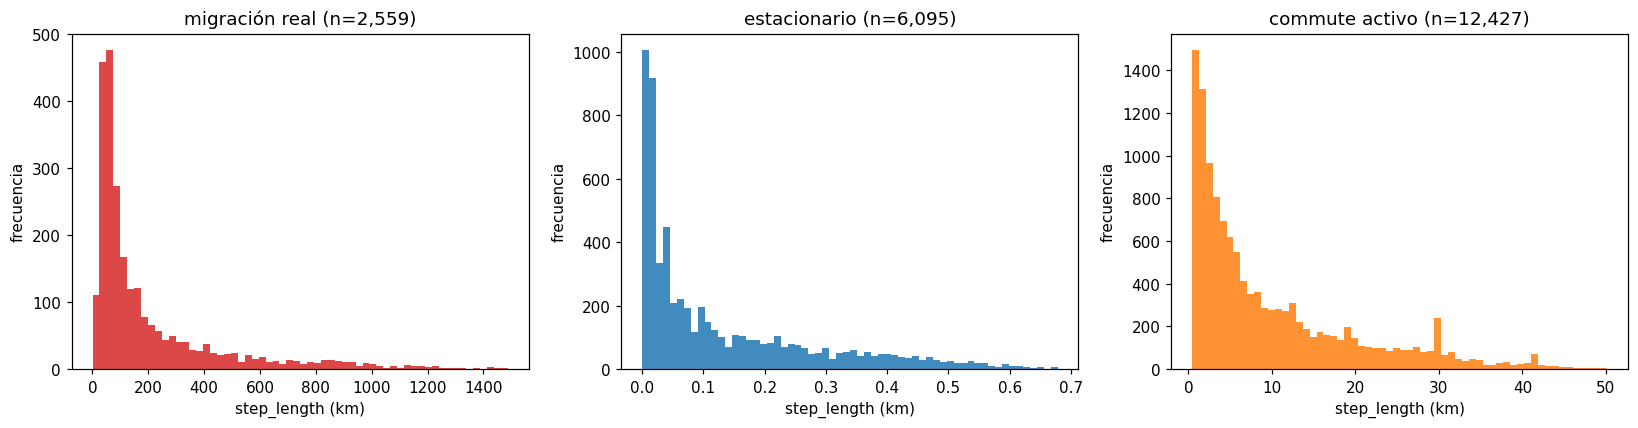

Cuantiles de step_length por estado:
                        count     mean      std    min      5%     25%  \
estado_hmm                                                               
migración real (0)  2559.0000 204.9800 250.7900 0.4300 28.2200 52.6800   
estacionario (1)    6095.0000   0.1300   0.1500 0.0000  0.0000  0.0200   
commute activo (2) 12427.0000   9.8700   9.9600 0.4300  0.8000  2.3300   

                       50%      75%      95%       max  
estado_hmm                                              
migración real (0) 95.1900 244.3100 801.0900 1487.8500  
estacionario (1)    0.0700   0.2100   0.4600    0.6800  
commute activo (2)  5.8500  14.1200  30.5500   50.1600  


In [13]:
# 7.3 — Histogramas de step_length por estado (3 paneles)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    (0, 'migración real',  axes[0], 'tab:red'),
    (1, 'estacionario',    axes[1], 'tab:blue'),
    (2, 'commute activo',  axes[2], 'tab:orange'),
]
for state, name, ax, color in panels:
    sub = df_hmm.loc[df_hmm['estado_hmm'] == state, 'step_length']
    ax.hist(sub, bins=60, color=color, alpha=0.85)
    ax.set_title(f'{name} (n={len(sub):,})')
    ax.set_xlabel('step_length (km)')
    ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

# Pequeño resumen numérico para apoyar la lectura de los histogramas
print('Cuantiles de step_length por estado:')
print(df_hmm.groupby('estado_hmm')['step_length']
      .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
      .rename(index=state_names)
      .round(2))

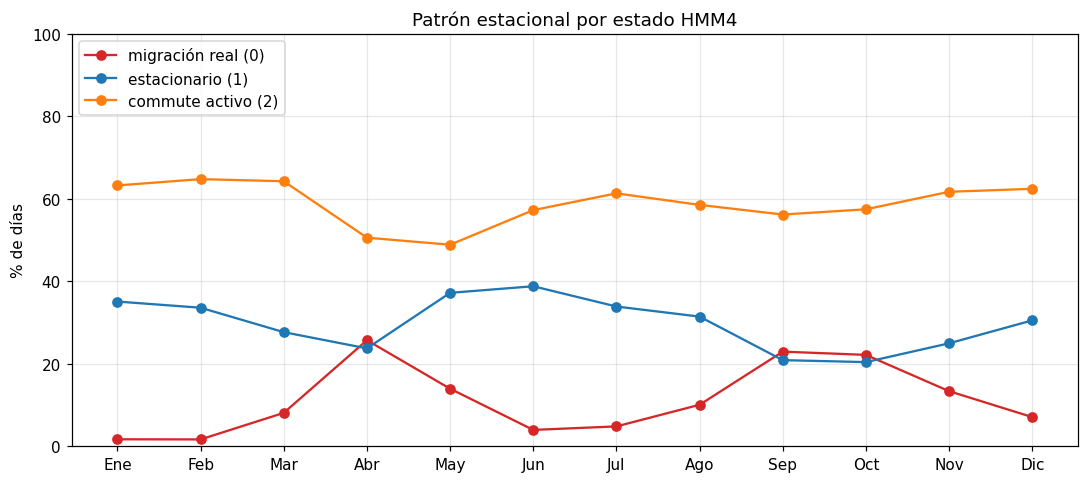


% por estado y mes:
     migración real (0)  estacionario (1)  commute activo (2)
mes                                                          
1                1.7000           35.1000             63.2000
2                1.7000           33.6000             64.7000
3                8.1000           27.7000             64.2000
4               25.7000           23.7000             50.6000
5               14.0000           37.2000             48.9000
6                4.0000           38.8000             57.2000
7                4.8000           33.9000             61.3000
8               10.1000           31.4000             58.5000
9               22.9000           20.9000             56.2000
10              22.2000           20.4000             57.4000
11              13.4000           25.0000             61.7000
12               7.1000           30.5000             62.4000


In [14]:
# 7.4 — Patrón estacional: % de días en cada estado por mes
df_hmm['mes'] = df_hmm['date'].dt.month
pct_by_state = (df_hmm.groupby(['mes', 'estado_hmm']).size()
                .unstack(fill_value=0)
                .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100))
pct_by_state.columns = [state_names[c] for c in pct_by_state.columns]

nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = {'migración real (0)': 'tab:red',
          'estacionario (1)': 'tab:blue',
          'commute activo (2)': 'tab:orange'}
for col in pct_by_state.columns:
    ax.plot(nombres, pct_by_state[col].values, marker='o', label=col, color=colors[col])
ax.set_ylabel('% de días')
ax.set_title('Patrón estacional por estado HMM4')
ax.set_ylim(0, 100)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n% por estado y mes:')
print(pct_by_state.round(1))

Ave ejemplo: 91916A (2026 días)


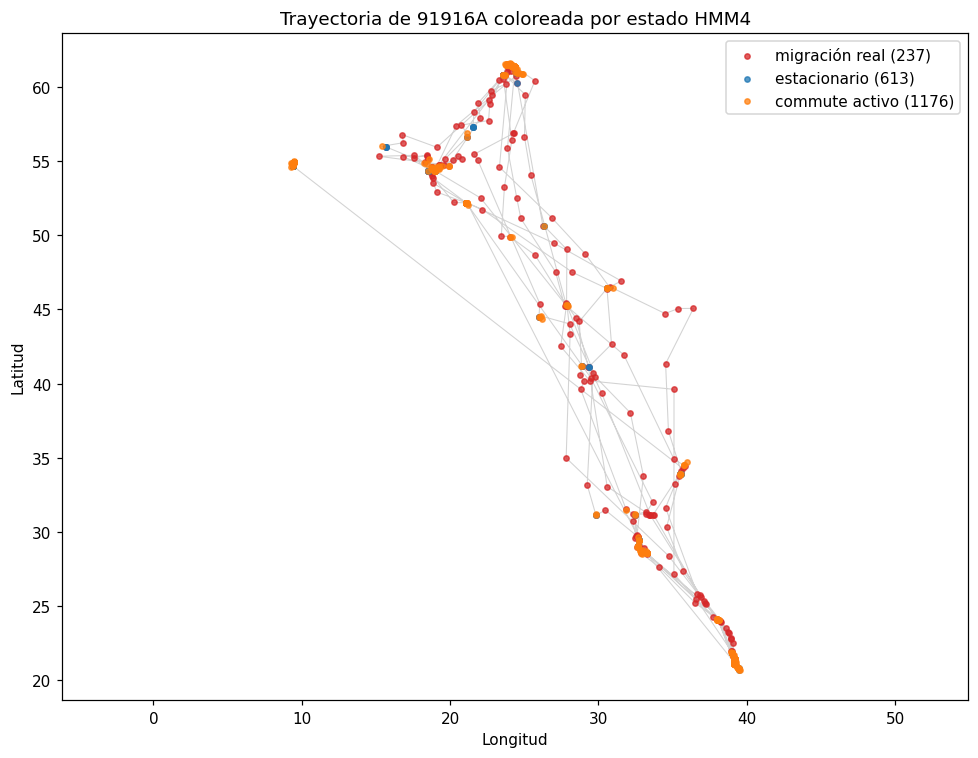

In [15]:
# 7.5 — Trayectoria de un ave coloreada por los 3 estados
ave_ej = df_hmm['animal_id'].value_counts().index[0]
sub = df_hmm[df_hmm['animal_id'] == ave_ej].sort_values('date')
print(f'Ave ejemplo: {ave_ej} ({len(sub)} días)')

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(sub['lon'], sub['lat'], color='lightgray', linewidth=0.7, zorder=1)
for state, name, color in [(0, 'migración real', 'tab:red'),
                            (1, 'estacionario',  'tab:blue'),
                            (2, 'commute activo','tab:orange')]:
    pts = sub[sub['estado_hmm'] == state]
    ax.scatter(pts['lon'], pts['lat'], s=12, c=color, label=f'{name} ({len(pts)})',
               alpha=0.75, zorder=2)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Trayectoria de {ave_ej} coloreada por estado HMM4')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.show()

## 8. Comparación HMM4 vs HMM2 — verificación de la hipótesis

Cargamos `hmm2.csv` y hacemos merge día a día con HMM4 sobre `(animal_id, date)`. Comprobamos los cuatro síntomas que motivaron HMM4:

1. **Tabla de contingencia 3×2**: ¿cómo se reparten los estados de HMM4 entre los dos de HMM2? La hipótesis es que `commute(HMM4)` cae mayoritariamente en `mig(HMM2)`, mientras que `mig real(HMM4)` ⊂ `mig(HMM2)` y `est(HMM4)` ⊂ `est(HMM2)`.
2. **% migración real en verano (jun-ago)**: debería bajar respecto al 14–21 % de HMM2.
3. **Mediana de la racha estacionaria**: debería subir respecto a los 4 días de HMM2.
4. **`|turning_angle|` medio en migración real (estado 0)**: debería bajar respecto a 1,52 rad de HMM2.

In [16]:
# 8.1 — Cargar HMM2 y hacer merge con HMM4 sobre (animal_id, date)
hmm2 = pd.read_csv('../data/processed/hmm2.csv')
hmm2['date'] = pd.to_datetime(hmm2['date'])
hmm2 = hmm2.rename(columns={'estado_hmm': 'estado_hmm2'})[['animal_id', 'date', 'estado_hmm2']]

merged = df_hmm.merge(hmm2, on=['animal_id', 'date'], how='inner')
merged = merged.rename(columns={'estado_hmm': 'estado_hmm4'})
print(f'Días emparejados HMM4↔HMM2: {len(merged):,} (de {len(df_hmm):,} en HMM4 y {len(hmm2):,} en HMM2)')

# 8.2 — Tabla de contingencia 3x2
ct = pd.crosstab(
    merged['estado_hmm4'].map(state_names),
    merged['estado_hmm2'].map({0: 'mig HMM2', 1: 'est HMM2'}),
    margins=True, margins_name='total',
)
print('\nTabla de contingencia HMM4 (filas) × HMM2 (columnas):')
print(ct)

# Mismo, en porcentaje por fila (cómo se reparte cada estado HMM4 dentro de los 2 de HMM2)
ct_pct = pd.crosstab(
    merged['estado_hmm4'].map(state_names),
    merged['estado_hmm2'].map({0: 'mig HMM2', 1: 'est HMM2'}),
    normalize='index',
) * 100
print('\nPorcentaje por fila (% de cada estado HMM4 que cae en mig/est HMM2):')
print(ct_pct.round(1))

Días emparejados HMM4↔HMM2: 21,081 (de 21,081 en HMM4 y 21,081 en HMM2)

Tabla de contingencia HMM4 (filas) × HMM2 (columnas):
estado_hmm2         est HMM2  mig HMM2  total
estado_hmm4                                  
commute activo (2)     10491      1936  12427
estacionario (1)        6086         9   6095
migración real (0)        28      2531   2559
total                  16605      4476  21081

Porcentaje por fila (% de cada estado HMM4 que cae en mig/est HMM2):
estado_hmm2         est HMM2  mig HMM2
estado_hmm4                           
commute activo (2)   84.4000   15.6000
estacionario (1)     99.9000    0.1000
migración real (0)    1.1000   98.9000


Patrón estacional — HMM2 vs HMM4:
     HMM2 — % migración  HMM4 — % migración real (0)  HMM4 — % commute (2)
Ene              7.1000                       1.7000               63.2000
Feb              9.0000                       1.7000               64.7000
Mar             16.9000                       8.1000               64.2000
Abr             34.0000                      25.7000               50.6000
May             23.1000                      14.0000               48.9000
Jun             14.9000                       4.0000               57.2000
Jul             19.1000                       4.8000               61.3000
Ago             18.2000                      10.1000               58.5000
Sep             31.9000                      22.9000               56.2000
Oct             32.7000                      22.2000               57.4000
Nov             22.5000                      13.4000               61.7000
Dic             14.5000                       7.1000              

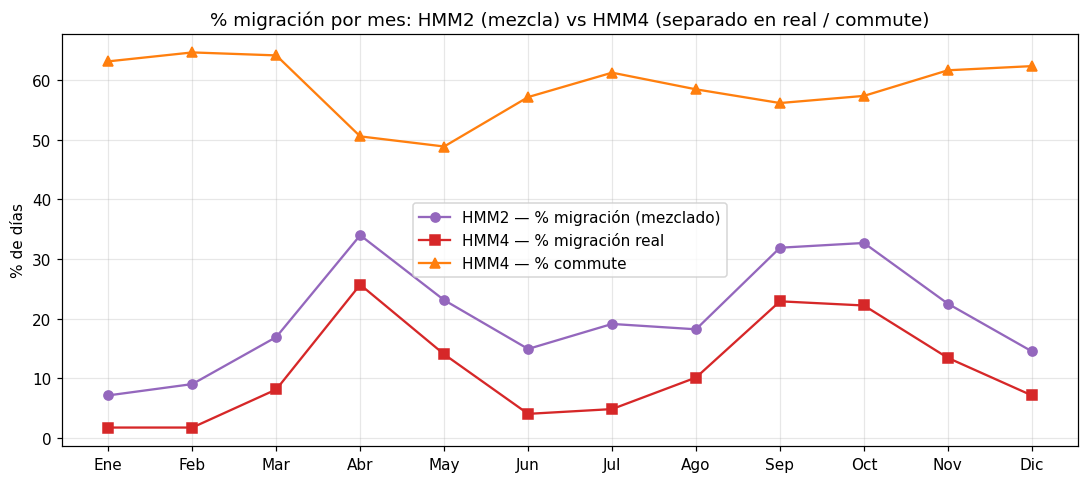

In [17]:
# 8.3 — Patrón estacional comparado: % de migración (HMM2) vs % de migración real (HMM4 estado 0)
merged['mes'] = merged['date'].dt.month
mig_hmm4 = merged.groupby('mes')['estado_hmm4'].apply(lambda s: (s == 0).mean() * 100)
mig_hmm2 = merged.groupby('mes')['estado_hmm2'].apply(lambda s: (s == 0).mean() * 100)
commute_hmm4 = merged.groupby('mes')['estado_hmm4'].apply(lambda s: (s == 2).mean() * 100)

comp_seasonal = pd.DataFrame({
    'HMM2 — % migración':           mig_hmm2.round(1),
    'HMM4 — % migración real (0)':  mig_hmm4.round(1),
    'HMM4 — % commute (2)':          commute_hmm4.round(1),
}, index=mig_hmm2.index)
comp_seasonal.index = nombres
print('Patrón estacional — HMM2 vs HMM4:')
print(comp_seasonal)

# Verano (jun-ago): la métrica clave de la hipótesis
verano = comp_seasonal.loc[['Jun', 'Jul', 'Ago']]
print('\nVerano (cría) — % migración:')
print(verano)
delta_verano = verano['HMM4 — % migración real (0)'].mean() - verano['HMM2 — % migración'].mean()
print(f'\nMedia jun-ago: HMM2 = {verano["HMM2 — % migración"].mean():.1f} %, '
      f'HMM4 mig real = {verano["HMM4 — % migración real (0)"].mean():.1f} %  '
      f'(Δ = {delta_verano:+.1f} pp)')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(nombres, comp_seasonal['HMM2 — % migración'].values, marker='o',
        label='HMM2 — % migración (mezclado)', color='tab:purple')
ax.plot(nombres, comp_seasonal['HMM4 — % migración real (0)'].values, marker='s',
        label='HMM4 — % migración real', color='tab:red')
ax.plot(nombres, comp_seasonal['HMM4 — % commute (2)'].values, marker='^',
        label='HMM4 — % commute', color='tab:orange')
ax.set_ylabel('% de días')
ax.set_title('% migración por mes: HMM2 (mezcla) vs HMM4 (separado en real / commute)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 8.4 — Run-length de estado estacionario: HMM2 vs HMM4
# Hipótesis: al separar el commute, las rachas de "estacionario" en HMM4 deberían ser
# más largas que en HMM2 (en HMM2 cualquier commute > 25 km rompía la racha de est).

def run_lengths(df_in, state_col, target_state):
    """Devuelve longitudes (días) de rachas consecutivas en target_state,
    respetando trayectoria_id (no encadena entre aves)."""
    out = []
    for _, g in df_in.sort_values(['trayectoria_id', 'date']).groupby('trayectoria_id', sort=False):
        s = (g[state_col] == target_state).astype(int).values
        run = 0
        for v in s:
            if v == 1:
                run += 1
            elif run > 0:
                out.append(run)
                run = 0
        if run > 0:
            out.append(run)
    return np.array(out)

# Necesitamos trayectoria_id en merged → reusamos df_hmm que ya lo tiene
merged_with_traj = (df_hmm[['animal_id', 'date', 'trayectoria_id', 'estado_hmm']]
                    .rename(columns={'estado_hmm': 'estado_hmm4'})
                    .merge(hmm2, on=['animal_id', 'date'], how='inner'))

rl_est_hmm4 = run_lengths(merged_with_traj, 'estado_hmm4', 1)  # 1 = estacionario en HMM4
rl_est_hmm2 = run_lengths(merged_with_traj, 'estado_hmm2', 1)  # 1 = estacionario en HMM2

print('Run-length de "estacionario" (días por racha):')
print(f'  HMM2 — n rachas = {len(rl_est_hmm2):>5d}, mediana = {np.median(rl_est_hmm2):.1f}, '
      f'media = {rl_est_hmm2.mean():.1f}, p90 = {np.percentile(rl_est_hmm2, 90):.0f}, '
      f'max = {rl_est_hmm2.max()}')
print(f'  HMM4 — n rachas = {len(rl_est_hmm4):>5d}, mediana = {np.median(rl_est_hmm4):.1f}, '
      f'media = {rl_est_hmm4.mean():.1f}, p90 = {np.percentile(rl_est_hmm4, 90):.0f}, '
      f'max = {rl_est_hmm4.max()}')
print(f'\nΔ mediana (HMM4 − HMM2) = {np.median(rl_est_hmm4) - np.median(rl_est_hmm2):+.1f} días')
print(f'Δ media   (HMM4 − HMM2) = {rl_est_hmm4.mean() - rl_est_hmm2.mean():+.1f} días')


Run-length de "estacionario" (días por racha):
  HMM2 — n rachas =  1693, mediana = 4.0, media = 9.8, p90 = 21, max = 482
  HMM4 — n rachas =  2304, mediana = 1.0, media = 2.6, p90 = 6, max = 55

Δ mediana (HMM4 − HMM2) = -3.0 días
Δ media   (HMM4 − HMM2) = -7.2 días


In [19]:
# 8.5 — |turning_angle| medio en migración real (HMM4) vs migración (HMM2)
# Hipótesis: aislando el vuelo recto de larga distancia, |turning_angle| en HMM4-mig real
# debería bajar respecto al 1,52 rad de HMM2-migración (cos→1, vuelo recto).

# Necesitamos turning_angle en merged → lo añadimos desde df_hmm
merged_with_turn = (df_hmm[['animal_id', 'date', 'turning_angle', 'step_length', 'estado_hmm']]
                    .rename(columns={'estado_hmm': 'estado_hmm4'})
                    .merge(hmm2, on=['animal_id', 'date'], how='inner'))

abs_turn = lambda s: np.abs(s).mean()

# HMM2: turning_angle medio en migración (estado_hmm2 == 0)
abs_turn_mig_hmm2 = abs_turn(merged_with_turn.loc[merged_with_turn['estado_hmm2'] == 0, 'turning_angle'])
step_mig_hmm2     = merged_with_turn.loc[merged_with_turn['estado_hmm2'] == 0, 'step_length'].mean()

# HMM4: turning_angle medio en cada uno de los 3 estados
rows = []
for s, name in state_names.items():
    sub = merged_with_turn[merged_with_turn['estado_hmm4'] == s]
    rows.append({
        'estado HMM4': name,
        'n días': len(sub),
        '|turn| medio (rad)': abs_turn(sub['turning_angle']),
        'step medio (km)':   sub['step_length'].mean(),
    })
abs_turn_table = pd.DataFrame(rows)
print('|turning_angle| y step medio por estado HMM4:')
print(abs_turn_table.round(3))

print(f'\nReferencia HMM2 — migración: |turn| medio = {abs_turn_mig_hmm2:.3f} rad, '
      f'step medio = {step_mig_hmm2:.1f} km')

abs_turn_mig_hmm4 = abs_turn(merged_with_turn.loc[merged_with_turn['estado_hmm4'] == 0, 'turning_angle'])
delta_turn = abs_turn_mig_hmm4 - abs_turn_mig_hmm2
print(f'\nΔ |turning_angle| en migración real (HMM4) − migración (HMM2) = {delta_turn:+.3f} rad')
print(f'  HMM2-mig:       {abs_turn_mig_hmm2:.3f} rad  (~{np.degrees(abs_turn_mig_hmm2):.0f}°)')
print(f'  HMM4-mig real:  {abs_turn_mig_hmm4:.3f} rad  (~{np.degrees(abs_turn_mig_hmm4):.0f}°)')
if delta_turn < -0.1:
    print('  → confirma hipótesis: el estado 0 de HMM4 captura vuelo más recto.')
else:
    print('  → no confirma hipótesis: la separación no reduce el giro medio en migración real.')


|turning_angle| y step medio por estado HMM4:
          estado HMM4  n días  |turn| medio (rad)  step medio (km)
0  migración real (0)    2559              1.1310         204.9760
1    estacionario (1)    6095              1.7820           0.1310
2  commute activo (2)   12427              2.0440           9.8660

Referencia HMM2 — migración: |turn| medio = 1.516 rad, step medio = 129.6 km

Δ |turning_angle| en migración real (HMM4) − migración (HMM2) = -0.385 rad
  HMM2-mig:       1.516 rad  (~87°)
  HMM4-mig real:  1.131 rad  (~65°)
  → confirma hipótesis: el estado 0 de HMM4 captura vuelo más recto.


## Conclusión — qué se gana al añadir un tercer estado

HMM4 es un experimento que rompe la restricción `n_components = 2` para verificar la caveat 1 de la Fase 5 de `HMM2_plan.md`. Las cuatro métricas clave (sección 8) responden a la pregunta de si un tercer estado separa los **vuelos largos reales** de los **commutes intra-residencia**:

1. **Tabla de contingencia HMM4×HMM2 (sección 8.2)**: si la hipótesis se cumple, `commute(HMM4)` cae mayoritariamente en `mig(HMM2)` y `est(HMM4)` ⊂ `est(HMM2)`. Esto demostraría que HMM2 efectivamente está empaquetando dos comportamientos distintos en una sola etiqueta.
2. **% migración real en verano (sección 8.3)**: si baja respecto al 14–21 % de HMM2, el tercer estado está absorbiendo los falsos positivos de migración durante la cría.
3. **Run-length de estacionario (sección 8.4)**: si la mediana sube respecto a los 4 días de HMM2, el commute ya no rompe las rachas de descanso.
4. **`|turning_angle|` medio en migración real (sección 8.5)**: si baja respecto a 1,52 rad de HMM2, el estado 0 captura vuelo más recto.

**Posición en el TFG**: HMM4 no sustituye a HMM2 (que respeta el enunciado de la profesora); cuantifica qué información se pierde con la restricción a dos estados. El resultado — sea cual sea — alimenta el análisis comparativo del trabajo (mismo papel que HMM3 con vegetación: experimento controlado, una variable cambiada respecto a la referencia).

Los resultados numéricos concretos y la valoración final se documentan en la **Fase 7 de `HMM2_plan.md`**, con la misma estructura que la Fase 6 (HMM3).